In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import timm
import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from skimage import io
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Dataset Cloning from kaggle

In [2]:
!git clone https://github.com/parth1620/Person-Re-Id-Dataset

Cloning into 'Person-Re-Id-Dataset'...
remote: Enumerating objects: 12942, done.
remote: Counting objects: 100% (12942/12942), done.
remote: Compressing objects: 100% (12942/12942), done.
remote: Total 12942 (delta 0), reused 12942 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12942/12942), 27.68 MiB | 23.78 MiB/s, done.


In [3]:
import sys
sys.path.append('/content/Person-Re-Id-Dataset')

# Configuratioins

In [4]:
DATA_DIR   = "/content/Person-Re-Id-Dataset/train/"
CSV_FILE   = "/content/Person-Re-Id-Dataset/train.csv"

BATCH_SIZE = 32
LR         = 0.001
EPOCHS     = 15
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

# ImageNet Normalisations

In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Data Augmentation as we have small dataset and to prevent overfitting

In [6]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),  # ImageNet norm
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),  # ImageNet norm
])

# Data Loading and Xploring

DATASET HEAD (first 5 rows of train.csv)
                    Anchor                 Negative                 Positive
0  1420_c5s3_052165_01.jpg  1334_c6s3_061492_05.jpg  1420_c3s3_051678_01.jpg
1  1420_c3s3_061978_03.jpg  0234_c3s3_079494_02.jpg  1420_c6s3_085567_02.jpg
2  1420_c5s3_062565_05.jpg  0475_c2s1_122816_08.jpg  1420_c3s3_051653_01.jpg
3  1420_c6s3_085592_04.jpg  0662_c2s2_036662_05.jpg  1420_c1s6_013446_04.jpg
4  0663_c5s3_085987_03.jpg  1463_c2s3_098102_02.jpg  0663_c3s3_085544_06.jpg

Total rows in CSV : 4000
Columns           : ['Anchor', 'Negative', 'Positive']


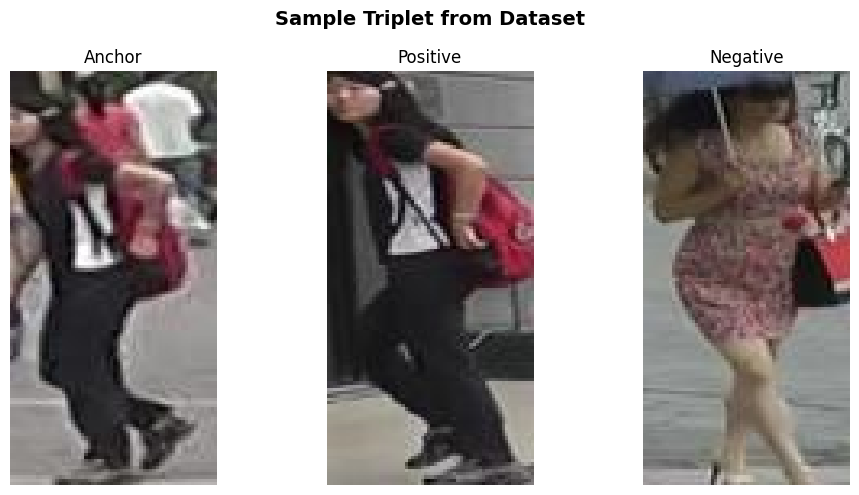

In [7]:
df = pd.read_csv(CSV_FILE)

print("=" * 60)
print("DATASET HEAD (first 5 rows of train.csv)")
print("=" * 60)
print(df.head())
print(f"\nTotal rows in CSV : {len(df)}")
print(f"Columns           : {list(df.columns)}")

row = df.iloc[4]
a_img = io.imread(DATA_DIR + row.Anchor)
p_img = io.imread(DATA_DIR + row.Positive)
n_img = io.imread(DATA_DIR + row.Negative)

f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 5))
f.suptitle("Sample Triplet from Dataset", fontsize=14, fontweight='bold')
ax1.set_title('Anchor');   ax1.imshow(a_img);   ax1.axis('off')
ax2.set_title('Positive'); ax2.imshow(p_img);   ax2.axis('off')
ax3.set_title('Negative'); ax3.imshow(n_img);   ax3.axis('off')
plt.tight_layout()
plt.savefig("sample_triplet.png", dpi=100)
plt.show()

In [8]:

train_df, valid_df = train_test_split(df, test_size=0.20, random_state=42)

# Custom Dataset creation..

In [9]:
class APN_Dataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        a_img = io.imread(DATA_DIR + row.Anchor)
        p_img = io.imread(DATA_DIR + row.Positive)
        n_img = io.imread(DATA_DIR + row.Negative)

        if self.transform:
            a_img = self.transform(a_img)
            p_img = self.transform(p_img)
            n_img = self.transform(n_img)
        else:
            a_img = torch.tensor(a_img).permute(2, 0, 1) / 255.0
            p_img = torch.tensor(p_img).permute(2, 0, 1) / 255.0
            n_img = torch.tensor(n_img).permute(2, 0, 1) / 255.0

        return a_img, p_img, n_img


trainset = APN_Dataset(train_df, transform=train_transform)
validset = APN_Dataset(valid_df, transform=val_transform)

print(f"\nSize of Trainset : {len(trainset)}")
print(f"Size of Validset : {len(validset)}")



Size of Trainset : 3200
Size of Validset : 800


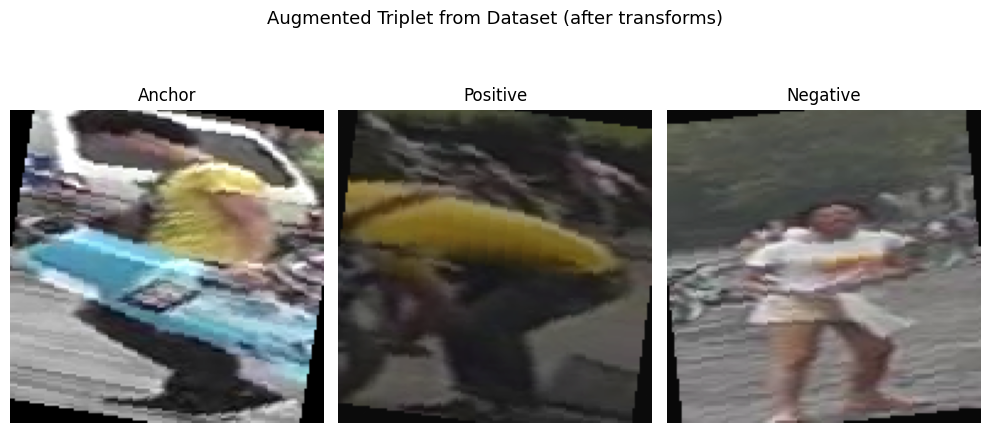

In [10]:
idx = 40
A, P, N = trainset[idx]

def denorm(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (t * std + mean).clamp(0, 1).numpy().transpose(1, 2, 0)

f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 5))
f.suptitle("Augmented Triplet from Dataset (after transforms)", fontsize=13)
ax1.set_title('Anchor');   ax1.imshow(denorm(A)); ax1.axis('off')
ax2.set_title('Positive'); ax2.imshow(denorm(P)); ax2.axis('off')
ax3.set_title('Negative'); ax3.imshow(denorm(N)); ax3.axis('off')
plt.tight_layout()
plt.savefig("augmented_triplet.png", dpi=100)
plt.show()

# Data loaders

In [11]:
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
validloader = DataLoader(validset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"\nNo. of batches in trainloader : {len(trainloader)}")
print(f"No. of batches in validloader : {len(validloader)}")

for A, P, N in trainloader:
    break
print(f"One image batch shape         : {A.shape}")


No. of batches in trainloader : 100
No. of batches in validloader : 25
One image batch shape         : torch.Size([32, 3, 128, 128])


# Model — EfficientNet-B0 backbone (pretrained)

In [12]:
class APN_Model(nn.Module):
    def __init__(self, emb_size=512):
        super(APN_Model, self).__init__()
        self.efficient = timm.create_model("efficientnet_b0", pretrained=True)
        self.efficient.classifier = nn.Linear(
            in_features=self.efficient.classifier.in_features,
            out_features=emb_size
        )

    def forward(self, images):
        embeddings = self.efficient(images)
        return embeddings

model = APN_Model()
model.to(DEVICE)
print(f"\nModel loaded on : {DEVICE}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]


Model loaded on : cuda


# Train and Eval funcitons


In [13]:
def train_fn(model, dataloader, optimizer, criterion):
    model.train()
    total_loss = 0
    for A, P, N in tqdm(dataloader, desc="Training"):
        A, P, N = A.to(DEVICE), P.to(DEVICE), N.to(DEVICE)
        A_embs = model(A)
        P_embs = model(P)
        N_embs = model(N)
        loss = criterion(A_embs, P_embs, N_embs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)


def eval_fn(model, dataloader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for A, P, N in tqdm(dataloader, desc="Validation"):
            A, P, N = A.to(DEVICE), P.to(DEVICE), N.to(DEVICE)
            A_embs = model(A)
            P_embs = model(P)
            N_embs = model(N)
            loss = criterion(A_embs, P_embs, N_embs)
            total_loss += loss.item()
    return total_loss / len(dataloader)


criterion = nn.TripletMarginLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Training

In [14]:
best_valid_loss = np.inf
train_losses, valid_losses = [], []

for epoch in range(EPOCHS):
    train_loss = train_fn(model, trainloader, optimizer, criterion)
    valid_loss = eval_fn(model, validloader, criterion)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    if valid_loss < best_valid_loss:
        torch.save(model.state_dict(), "best_model.pt")
        best_valid_loss = valid_loss
        print("  ✓ Saved best weights")

    print(f"Epoch {epoch+1:02d}/{EPOCHS}  train_loss: {train_loss:.4f}  valid_loss: {valid_loss:.4f}")

Validation: 100%|██████████| 25/25 [00:03<00:00,  6.90it/s]


  ✓ Saved best weights
Epoch 01/15  train_loss: 0.6032  valid_loss: 0.3008


Validation: 100%|██████████| 25/25 [00:03<00:00,  6.99it/s]


  ✓ Saved best weights
Epoch 02/15  train_loss: 0.3020  valid_loss: 0.2408


Validation: 100%|██████████| 25/25 [00:03<00:00,  6.88it/s]


...

  ✓ Saved best weights
Epoch 13/15  train_loss: 0.0441  valid_loss: 0.0982


Validation: 100%|██████████| 25/25 [00:04<00:00,  5.10it/s]


  ✓ Saved best weights
Epoch 14/15  train_loss: 0.0403  valid_loss: 0.0907


Validation: 100%|██████████| 25/25 [00:03<00:00,  6.50it/s]

Epoch 15/15  train_loss: 0.0436  valid_loss: 0.1289


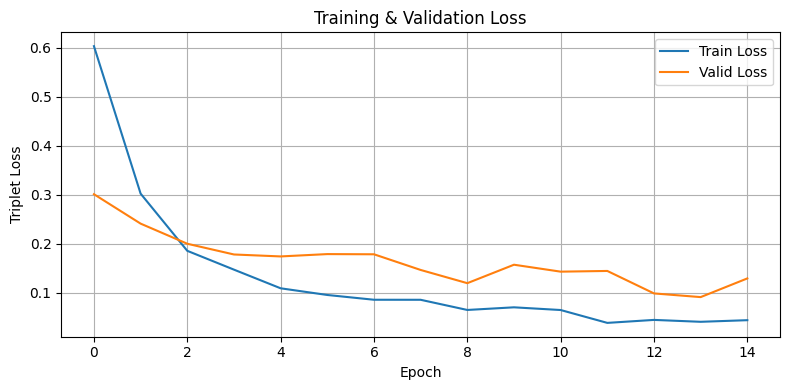

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(valid_losses, label="Valid Loss")
plt.xlabel("Epoch"); plt.ylabel("Triplet Loss")
plt.title("Training & Validation Loss")
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=100)
plt.show()

# Vectorised Inference
Embeddings DB

In [16]:
@torch.no_grad()
def get_encoding_csv(model, anc_img_names, transform, batch_size=64):

    model.eval()
    encodings = []
    imgs_batch = []
    names_order = list(anc_img_names)

    for i, name in enumerate(tqdm(names_order, desc="Building embedding DB")):
        img = io.imread(DATA_DIR + name)
        img = transform(img)
        imgs_batch.append(img)

        if len(imgs_batch) == batch_size or i == len(names_order) - 1:
            batch = torch.stack(imgs_batch).to(DEVICE)
            embs  = model(batch).cpu().numpy()
            encodings.append(embs)
            imgs_batch = []

    encodings = np.vstack(encodings)
    enc_df    = pd.DataFrame(encodings)
    df_enc    = pd.concat([pd.Series(names_order, name="Anchor"), enc_df], axis=1)
    return df_enc


model.load_state_dict(torch.load("best_model.pt"))
df_enc = get_encoding_csv(model, df["Anchor"], val_transform)

df_enc.to_csv("database.csv", index=False)

print("\n" + "=" * 60)
print("ENCODING DATABASE HEAD (first 5 rows)")
print("=" * 60)
print(df_enc.head())
print(f"\nShape of encoding matrix : {df_enc.shape}")
print(f"  → {df_enc.shape[0]} images × {df_enc.shape[1]-1} embedding dimensions")



Building embedding DB: 100%|██████████| 4000/4000 [00:08<00:00, 495.73it/s]



ENCODING DATABASE HEAD (first 5 rows)
                    Anchor         0         1         2         3         4  \
0  1420_c5s3_052165_01.jpg -0.160841  0.257140  0.129204  0.254553  0.368069   
1  1420_c3s3_061978_03.jpg -0.196450 -0.145889  0.227359  0.310683  0.478359   
2  1420_c5s3_062565_05.jpg -0.200276  0.186691  0.115851  0.137721  0.431292   
3  1420_c6s3_085592_04.jpg -0.203494  0.246555  0.105448  0.301043  0.526448   
4  0663_c5s3_085987_03.jpg -0.467604  0.472661  0.050062 -0.647800  0.181523   

          5         6         7         8  ...       502       503       504  \
0 -0.424488 -0.282860  0.319601  0.111302  ... -0.342641  1.321177 -0.562926   
1 -0.376537 -0.084016  0.317505  0.045738  ... -0.571003  1.090587 -0.225903   
2 -0.325645 -0.205859  0.313873  0.207743  ... -0.343645  1.063291 -0.479504   
3 -0.446363 -0.355385  0.143604  0.030733  ... -0.075993  1.333646 -0.631939   
4 -0.084417 -0.325433  0.036971  0.136431  ...  0.926419  1.042119 -0.712737   


# Testing

In [23]:
idx      = 80
img_name = df_enc["Anchor"].iloc[idx]
img_path = DATA_DIR + img_name
img_raw  = io.imread(img_path)

img_tensor = val_transform(img_raw).unsqueeze(0).to(DEVICE)
model.eval()
with torch.no_grad():
    img_enc = model(img_tensor).cpu().numpy()


anc_enc_arr  = df_enc.iloc[:, 1:].to_numpy()
anc_img_names = df_enc["Anchor"]

In [24]:
diff      = img_enc - anc_enc_arr
distance  = np.sqrt((diff ** 2).sum(axis=1))
closest_idx = np.argsort(distance)

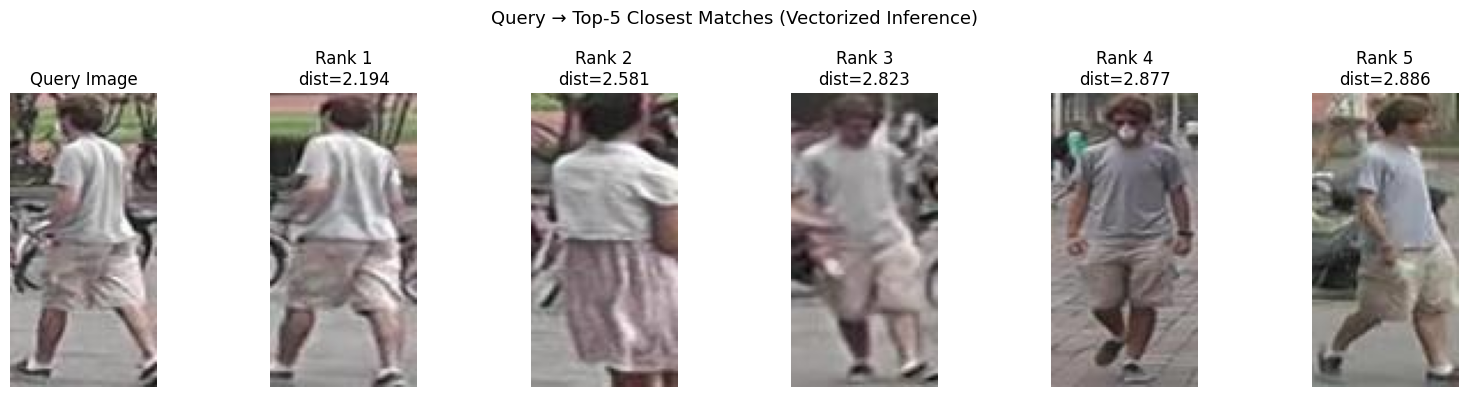

In [25]:
NO_OF_CLOSEST = 5
fig, axes = plt.subplots(1, NO_OF_CLOSEST + 1, figsize=(16, 4))
fig.suptitle("Query → Top-5 Closest Matches (Vectorized Inference)", fontsize=13)

axes[0].imshow(img_raw)
axes[0].set_title("Query Image")
axes[0].axis("off")

for rank, ci in enumerate(closest_idx[1 : NO_OF_CLOSEST + 1]):
    match_img = io.imread(DATA_DIR + anc_img_names.iloc[ci])
    axes[rank + 1].imshow(match_img)
    axes[rank + 1].set_title(f"Rank {rank+1}\ndist={distance[ci]:.3f}")
    axes[rank + 1].axis("off")

plt.tight_layout()
plt.savefig("top5_matches.png", dpi=100)
plt.show()